BEGINNER TASK 1
Exploratory Data Analysis (EDA)

Submitted by Kessington Godspower Osazenomwan

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [34]:
train = pd.read_csv('C:/Users/HomePC/Desktop/train.csv')
train.head()

,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0


In [33]:
train.shape
train.columns
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000888 entries, 0 to 3000887
Data columns (total 6 columns):
 #   Column       Dtype         
---  ------       -----         
 0   id           int64         
 1   date         datetime64[ns]
 2   store_nbr    int64         
 3   family       object        
 4   sales        float64       
 5   onpromotion  int64         
dtypes: datetime64[ns](1), float64(1), int64(3), object(1)
memory usage: 137.4+ MB


In [26]:
print(train.isnull().sum())

id             0
date           0
store_nbr      0
family         0
sales          0
onpromotion    0
dtype: int64


In [31]:
train.describe(include='all')

,id,date,store_nbr,family,sales,onpromotion
count,3.000888e+06,3000888,3.000888e+06,3000888,3.000888e+06,3.000888e+06
unique,NaN,NaN,NaN,33,NaN,NaN
top,NaN,NaN,NaN,AUTOMOTIVE,NaN,NaN
freq,NaN,NaN,NaN,90936,NaN,NaN
mean,1.500444e+06,2015-04-24 08:27:04.703088384,2.750000e+01,NaN,3.577757e+02,2.602770e+00
min,0.000000e+00,2013-01-01 00:00:00,1.000000e+00,NaN,0.000000e+00,0.000000e+00
25%,7.502218e+05,2014-02-26 18:00:00,1.400000e+01,NaN,0.000000e+00,0.000000e+00
50%,1.500444e+06,2015-04-24 12:00:00,2.750000e+01,NaN,1.100000e+01,0.000000e+00
75%,2.250665e+06,2016-06-19 06:00:00,4.100000e+01,NaN,1.958473e+02,0.000000e+00
max,3.000887e+06,2017-08-15 00:00:00,5.400000e+01,NaN,1.247170e+05,7.410000e+02


In [35]:
import pandas as pd
train = pd.read_csv('C:/Users/HomePC/Desktop/train.csv')
train.columns = train.columns.str.strip()
train['date'] = pd.to_datetime(train['date'], errors='coerce')
train.head()
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000888 entries, 0 to 3000887
Data columns (total 6 columns):
 #   Column       Dtype         
---  ------       -----         
 0   id           int64         
 1   date         datetime64[ns]
 2   store_nbr    int64         
 3   family       object        
 4   sales        float64       
 5   onpromotion  int64         
dtypes: datetime64[ns](1), float64(1), int64(3), object(1)
memory usage: 137.4+ MB


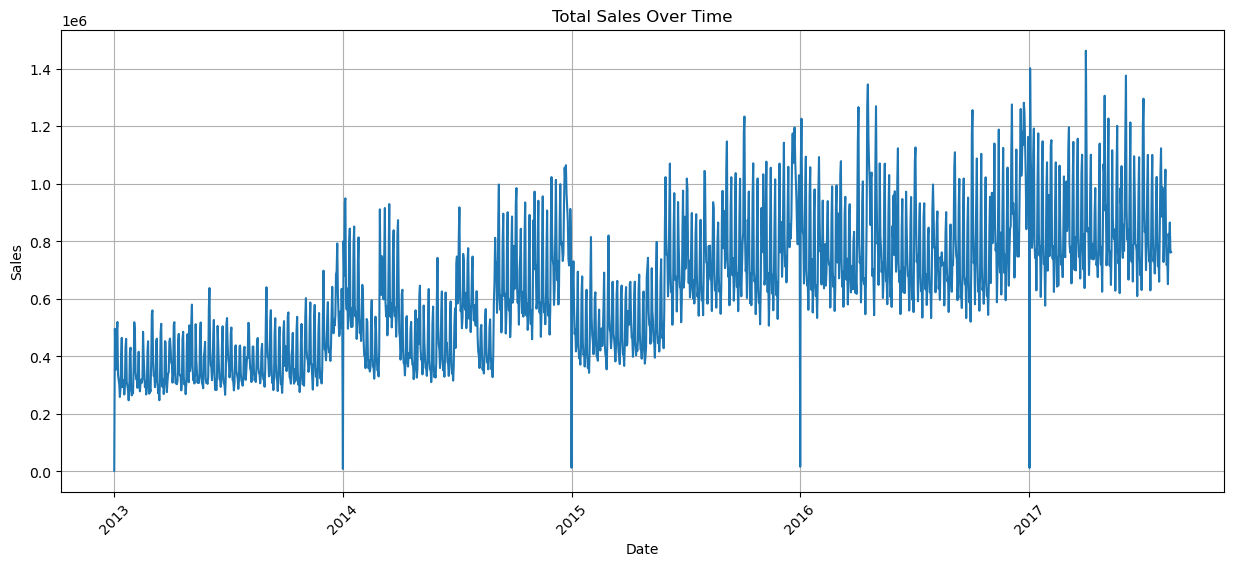

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
train = pd.read_csv('C:/Users/HomePC/Desktop/train.csv')
train['date'] = pd.to_datetime(train['date'])
sales_trend = train.groupby('date')['sales'].sum().reset_index()
plt.figure(figsize=(15,6))
plt.plot(sales_trend['date'],sales_trend['sales'])
plt.title('Total Sales Over Time')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

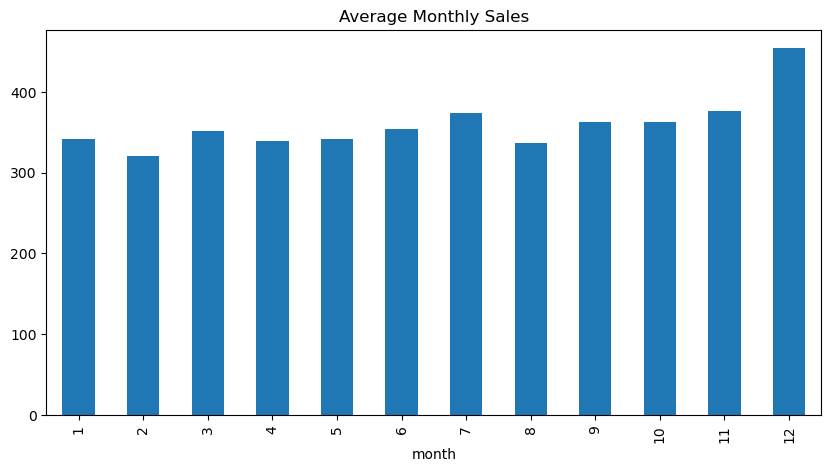

In [36]:
train['month'] = train['date'].dt.month

monthly_sales = train.groupby('month')['sales'].mean()

plt.figure(figsize=(10,5))
monthly_sales.plot(kind='bar')
plt.title('Average Monthly Sales')
plt.show()

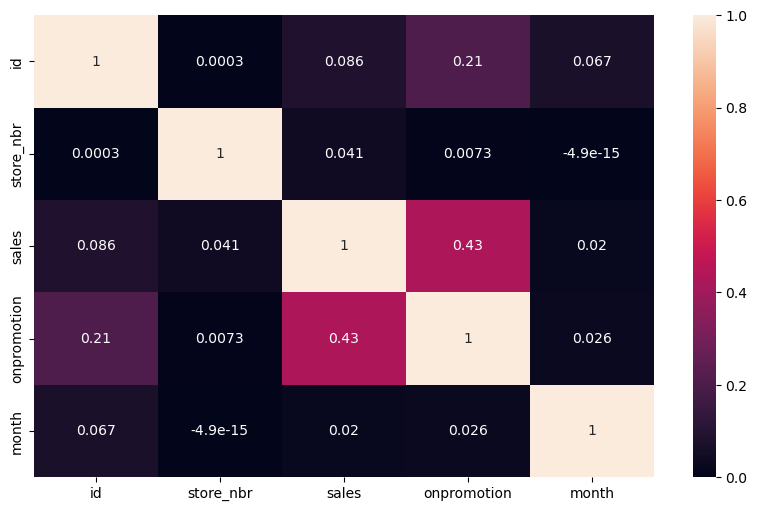

In [37]:
numeric_data = train.select_dtypes(include=np.number)

plt.figure(figsize=(10,6))
sns.heatmap(numeric_data.corr(), annot=True)
plt.show()

BEGINNER TASK 2
Moving Average Forecast

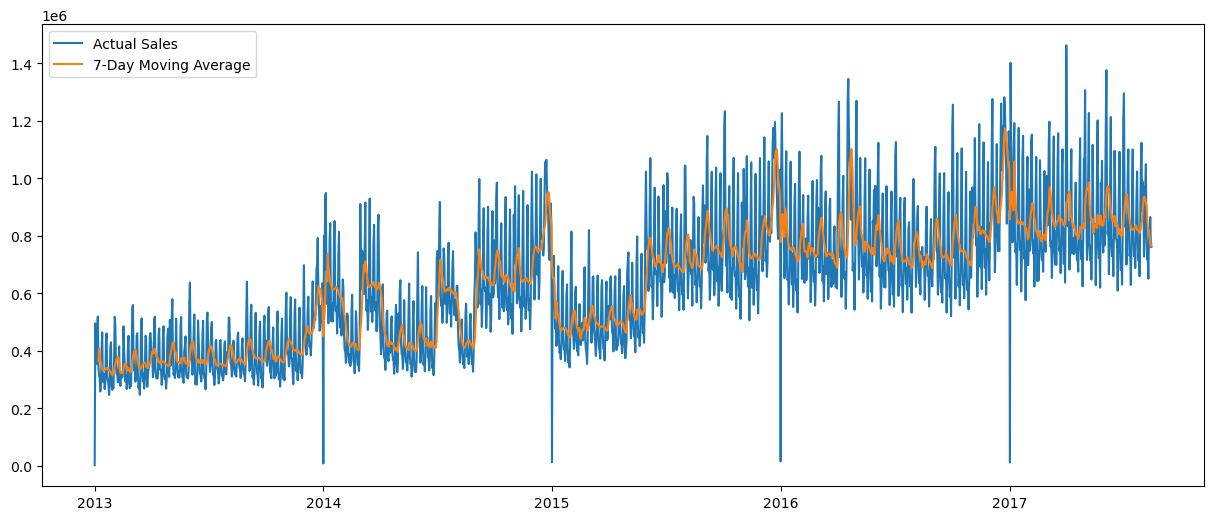

In [44]:
sales_trend = sales_trend.reset_index()
sales_trend['7_day_MA'] = sales_trend['sales'].rolling(window=7).mean()

plt.figure(figsize=(15,6))
plt.plot(sales_trend['date'], sales_trend['sales'], label='Actual Sales')
plt.plot(sales_trend['date'], sales_trend['7_day_MA'], label='7-Day Moving Average')
plt.legend()
plt.show()

BEGINNER TASK 3
Linear Regression Model

In [45]:
train['year'] = train['date'].dt.year
train['month'] = train['date'].dt.month
train['day'] = train['date'].dt.day

In [46]:
X = train[['store_nbr', 'family', 'onpromotion', 'year', 'month', 'day']]
y = train['sales']

In [47]:
X = pd.get_dummies(X, columns=['family'], drop_first=True)

In [48]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [49]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [50]:
predictions = model.predict(X_test)

In [51]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)

print('MAE:', mae)
print('MSE:', mse)

MAE: 260.12438342521494
MSE: 577588.5867551616


INTERMEDIATE TASK 1
Feature Engineering

In [53]:
train['weekday'] = train['date'].dt.weekday
train['is_weekend'] = train['weekday'].isin([5,6]).astype(int)

In [54]:
train = train.sort_values('date')

train['lag_7'] = train['sales'].shift(7)
train['lag_30'] = train['sales'].shift(30)

In [55]:
train['rolling_mean_7'] = train['sales'].rolling(7).mean()

INTERMEDIATE TASK 2
Multiple Regression

In [56]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [57]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, predictions))
print('RMSE:', rmse)

RMSE: 759.9924912491975


ADVANCED LEVEL TASK — PART 1
Regularized Regression (Ridge & Lasso)

In [58]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X_train)

ADVANCED LEVEL TASK — PART 3
Model Deployment with Streamlit

In [61]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

In [62]:
train = pd.read_csv('C:/Users/HomePC/Desktop/train.csv')

oil = pd.read_csv('C:/Users/HomePC/Desktop/oil.csv')

transactions = pd.read_csv('C:/Users/HomePC/Desktop/transactions.csv')

In [63]:
train['date'] = pd.to_datetime(train['date'])

oil['date'] = pd.to_datetime(oil['date'])

transactions['date'] = pd.to_datetime(
    transactions['date']
)

In [64]:
train = train.merge(oil,on='date',how='left')
train = train.merge(transactions,on=['date', 'store_nbr'],how='left')

In [65]:
train.fillna(0, inplace=True)

In [66]:
train['year'] = train['date'].dt.year
train['month'] = train['date'].dt.month
train['day'] = train['date'].dt.day
train['weekday'] = train['date'].dt.weekday

In [67]:
X = train[['store_nbr','onpromotion','dcoilwtico','transactions','year','month','day','weekday']]
y = train['sales']

In [68]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [69]:
predictions = model.predict(X_test)
mae = mean_absolute_error(y_test,predictions)
rmse = np.sqrt(mean_squared_error(y_test,predictions))
print('MAE:', mae)
print('RMSE:', rmse)

MAE: 420.77396241627474
RMSE: 978.4625550783329


ADVANCED LEVEL TASK — PART 2
Regression with External Data

In [70]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (mean_absolute_error,mean_squared_error)

In [71]:
train = pd.read_csv('C:/Users/HomePC/Desktop/train.csv')

oil = pd.read_csv('C:/Users/HomePC/Desktop/oil.csv')

transactions = pd.read_csv('C:/Users/HomePC/Desktop/transactions.csv')

In [72]:
train = train.merge(
    oil,
    on='date',
    how='left')


train = train.merge(
    transactions,
    on=['date', 'store_nbr'],
    how='left')

train.fillna(0, inplace=True)

In [82]:
import pandas as pd
train['date'] = pd.to_datetime(train['date'], errors='coerce')

train['year'] = train['date'].dt.year
train['month'] = train['date'].dt.month
train['day'] = train['date'].dt.day
train['weekday'] = train['date'].dt.weekday

In [85]:
X = train[[
    'store_nbr',
    'onpromotion',
    'year',
    'month',
    'day',
    'weekday']]
y = train['sales']


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42)


model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [86]:
predictions = model.predict(X_test)
mae = mean_absolute_error(y_test,predictions)
rmse = np.sqrt(mean_squared_error(y_test,predictions))
print('MAE:', mae)
print('RMSE:', rmse)

MAE: 435.42024585849055
RMSE: 1007.0005333060163


ADVANCED LEVEL TASK — PART 3
Model Deployment with Streamlit

In [89]:
import os
import pickle
if not os.path.exists('models'):os.makedirs('models')
pickle.dump(model,open('models/model.pkl', 'wb'))

In [90]:
import streamlit as st
import pandas as pd

model = pickle.load(open('models/model.pkl', 'rb'))

st.title('Sales Forecast Dashboard')
st.write('Predict future store sales')

2026-05-12 13:15:23.123 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-12 13:15:23.393 
  command:

    streamlit run C:\Users\HomePC\anaconda3\Lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-05-12 13:15:23.394 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-12 13:15:23.396 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-12 13:15:23.397 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-12 13:15:23.399 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-12 13:15:23.401 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


In [91]:
store_nbr = st.number_input('Store Number',min_value=1)
promotion = st.number_input('Promotion Count',min_value=0)
oil_price = st.number_input('Oil Price')
transactions = st.number_input('Transactions')
month = st.number_input('Month',min_value=1,max_value=12)
day = st.number_input('Day',min_value=1,max_value=31)
weekday = st.number_input('Weekday',min_value=0,max_value=6)
year = st.number_input('Year',min_value=2013,max_value=2030)

if st.button('Predict Sales'):
    input_data = pd.DataFrame({'store_nbr': [store_nbr],'onpromotion': [promotion],'year': [year],'month': [month],'day': [day],'weekday': [weekday]})

    prediction = model.predict(input_data)
    st.success(f'Predicted Sales: {prediction[0]:.2f}')

2026-05-12 13:21:13.342 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-12 13:21:13.344 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-12 13:21:13.345 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-12 13:21:13.348 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-12 13:21:13.350 Session state does not function when running a script without `streamlit run`
2026-05-12 13:21:13.352 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-12 13:21:13.353 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-12 13:21:13.354 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-12 13:21

MORE ADVANCED LEVEL (OPTIONAL)
Hybrid Forecasting System

In [119]:
!conda install -c conda-forge xgboost -y

Jupyter detected...
3 channel Terms of Service accepted
Retrieving notices: done
Channels:
 - conda-forge
 - defaults
Platform: win-64


Retrying (Retry(total=2, connect=None, read=None, redirect=None, status=None)) after connection broken by 'ConnectTimeoutError(<urllib3.connection.HTTPSConnection object at 0x0000021AB0DE52B0>, 'Connection to conda.anaconda.org timed out. (connect timeout=5)')': /t/<TOKEN>/conda-forge/win-64

Retrying (Retry(total=2, connect=None, read=None, redirect=None, status=None)) after connection broken by 'ConnectTimeoutError(<urllib3.connection.HTTPSConnection object at 0x0000021AB0205BD0>, 'Connection to repo.anaconda.com timed out. (connect timeout=5)')': /pkgs/r/notices.json

Retrying (Retry(total=2, connect=None, read=None, redirect=None, status=None)) after connection broken by 'ConnectTimeoutError(<urllib3.connection.HTTPSConnection object at 0x0000021AB02056D0>, 'Connection to repo.anaconda.com timed out. (connect timeout=5)')': /pkgs/msys2/notices.json

Retrying (Retry(total=2, connect=None, read=None, redirect=None, status=None)) after connection broken by 'ConnectTimeoutError(<urllib

In [113]:
import sys
!{sys.executable} -m pip install xgboost

In [123]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import (mean_absolute_error,mean_squared_error)
from sklearn.linear_model import Ridge
from xgboost import XGBRegressor

In [107]:
train = pd.read_csv('C:/Users/HomePC/Desktop/train.csv')
train['date'] = pd.to_datetime(train['date'])
train['year'] = train['date'].dt.year
train['month'] = train['date'].dt.month
train['day'] = train['date'].dt.day
train['weekday'] = train['date'].dt.weekday

In [108]:
train = train.sort_values('date')
train['lag_7'] = train['sales'].shift(7)
train['lag_30'] = train['sales'].shift(30)

train.dropna(inplace=True)

In [109]:
X = train[['store_nbr','onpromotion','year','month','day','weekday','lag_7','lag_30']]
y = train['sales']

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [110]:
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)
ridge_predictions = ridge_model.predict(X_test)

In [124]:
xgb_model = XGBRegressor(n_estimators=100,learning_rate=0.1,max_depth=6,random_state=42)
xgb_model.fit(X_train, y_train)
xgb_predictions = xgb_model.predict(X_test)

final_predictions = (ridge_predictions + xgb_predictions) / 2
mae = mean_absolute_error(y_test,final_predictions)
rmse = np.sqrt(mean_squared_error(y_test,final_predictions))
print('Hybrid Model MAE:', mae)
print('Hybrid Model RMSE:', rmse)

Hybrid Model MAE: 363.67186254545106
Hybrid Model RMSE: 840.533985196838
